In [2]:
import pandas as pd

In [14]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [15]:
df.shape

(1338, 7)

In [16]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [19]:
def check_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T
check_types_table(df)

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,str,float64,int64,str,str,float64
Num_Unique,47,2,548,6,2,4,1337


In [20]:
cols = ['sex','smoker','region']
df[cols] = df[cols].astype('category')

In [21]:
check_types_table(df)

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,category,float64,int64,category,category,float64
Num_Unique,47,2,548,6,2,4,1337


## isnull() and isna() are the same but i'll use both

In [28]:
def check_null_table(data):
    null = data.isnull().sum()
    ratio = (null/ data.shape[0])*100
    return pd.DataFrame({"Null":null, "ratio % ":ratio}).T
check_null_table(df)

,age,sex,bmi,children,smoker,region,charges
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
def check_na_table(data):
    na = data.isna().sum()
    ratio = (na/ data.shape[0])*100
    return pd.DataFrame({"NA":na, "ratio % ":ratio}).T
check_na_table(df)

,age,sex,bmi,children,smoker,region,charges
NA,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
df.dtypes

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

In [35]:
df['sex'].unique()

['female', 'male']
Categories (2, str): ['female', 'male']

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

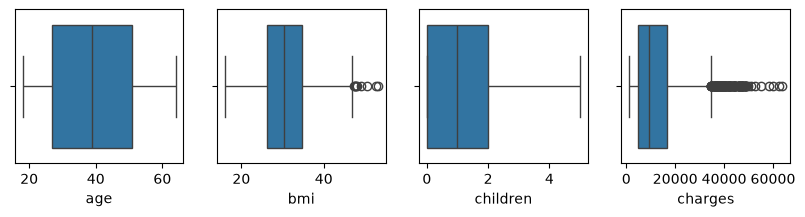

In [42]:
num_cols  =  df.select_dtypes('number').columns
plt.figure(figsize=(10,2))
for i , col in enumerate(num_cols):
    plt.subplot(1,len(num_cols), i+1)
    sns.boxplot(df[col],orient='h')

## IQR

In [44]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5* IQR
    upper_fence = Q3 +   1.5* IQR
    # print(lower_fence)
    lower_outliers = df[   df[col] < lower_fence    ][col].values 
    upper_outliers = df[ df[col] > upper_fence][col].values 

    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)



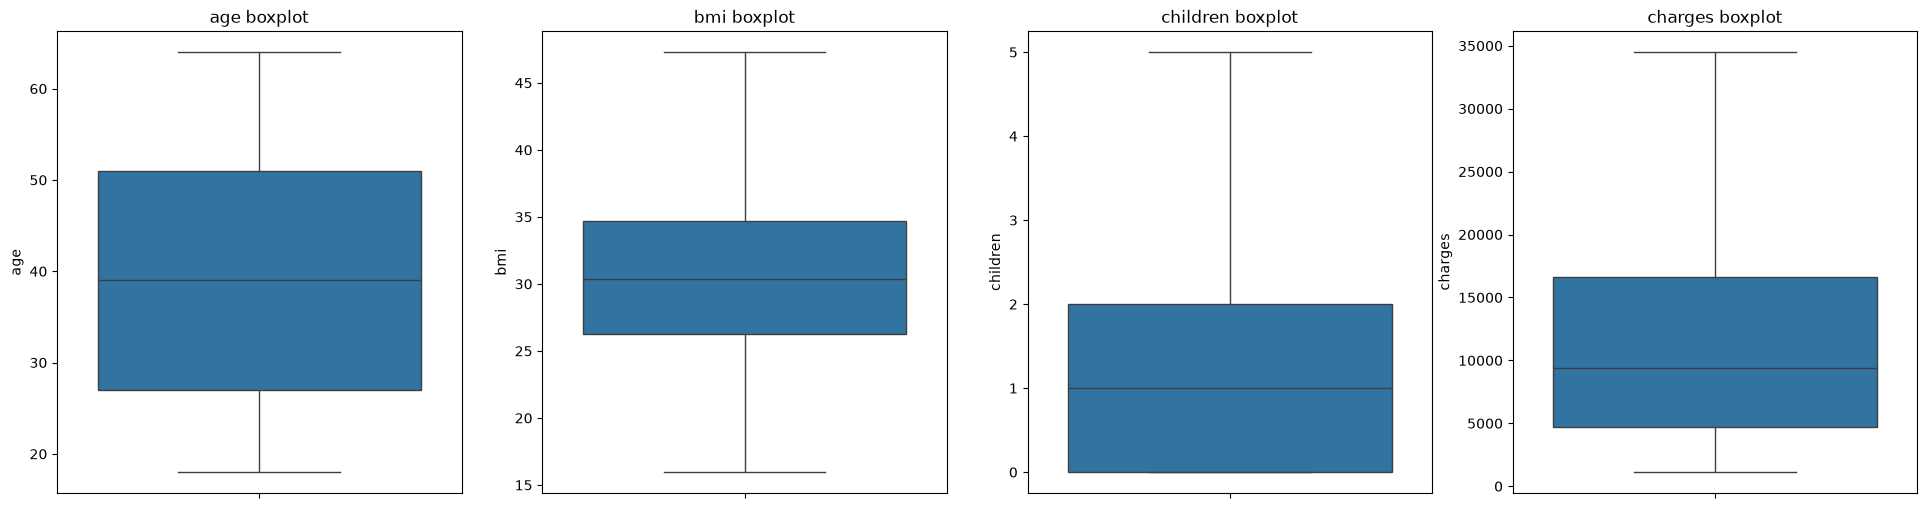

In [62]:
plt.figure(figsize=(6*len(num_cols),6))
for i, col in enumerate(num_cols):
    plt.subplot(1,len(num_cols),i+1)
    sns.boxplot(y=df[col],orient='v')
    plt.title(f"{col} boxplot")

In [70]:
df.duplicated().sum()

np.int64(1)

In [72]:
df.drop_duplicates(inplace=True)

In [74]:
df.duplicated().sum()

np.int64(0)

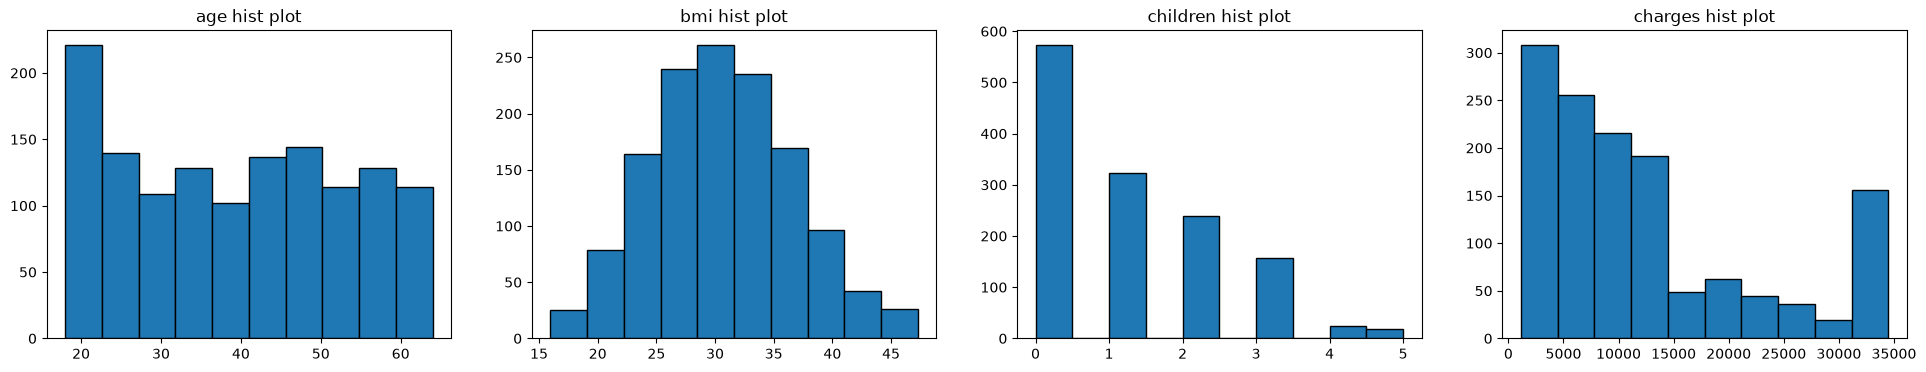

In [ ]:
plt.figure(figsize=(6*len(num_cols),4))
for i , col in enumerate(num_cols):
    plt.subplot(1 , len(num_cols) , i+1)
    plt.hist(df[col] ,  edgecolor = "black")
    plt.title(f"{col} hist plot")
plt.show()

In [81]:
cat_cols= df.select_dtypes("category").columns
cat_cols

Index(['sex', 'smoker', 'region'], dtype='str')

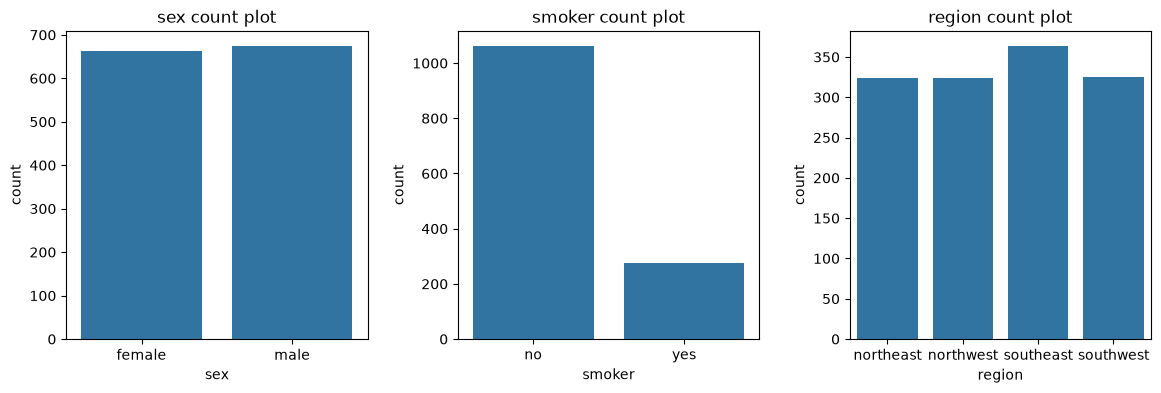

In [83]:
plt.figure(figsize=(14,4))
for i , cols in enumerate(cat_cols):
    plt.subplot(1,3 , i+1)
    sns.countplot(x = cols , data=df)
    plt.title(f"{cols} count plot")
plt.subplots_adjust(hspace= .8 ,  wspace=.3)  

In [87]:
unique = df["sex"].value_counts()
print(unique)
count = unique.values
categories = unique.index

sex
male      675
female    662
Name: count, dtype: int64


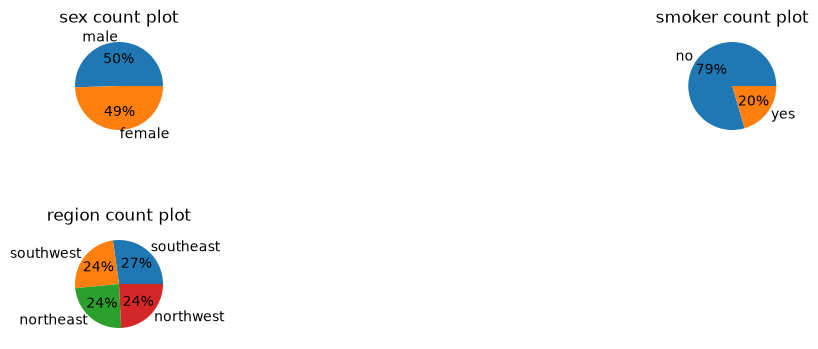

In [89]:
plt.figure(figsize=(14,4))
for i , cols in enumerate(cat_cols):
    plt.subplot(2,2 , i+1)
    unique = df[cols].value_counts()
    count = unique.values
    categories = unique.index
    plt.title(f"{cols} count plot")
    plt.pie(count ,  labels=categories , autopct= '%1.1d%%')
plt.subplots_adjust(hspace= .8 ,  wspace=.3)    

In [99]:
import plotly.express as px
fig = px.pie(df , names =  "sex",
        color_discrete_sequence=px.colors.qualitative.Pastel,
        hole=.6 )
fig.update_layout(annotations =  [dict(text= "Gender" ,  font_size  =20 , x = .5, y =.5 , showarrow = False)])

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'domain': {'x': [0.0, 1.0], 'y': [0.0, 1.0]},
              'hole': 0.6,
              'hovertemplate': 'sex=%{label}<extra></extra>',
              'labels': array(['female', 'male', 'male', ..., 'female', 'female', 'female'],
                              shape=(1337,), dtype=object),
              'legendgroup': '',
              'name': '',
              'showlegend': True,
              'type': 'pie'}],
    'layout': {'annotations': [{'font': {'size': 20}, 'showarrow': False, 'text': 'Gender', 'x': 0.5, 'y': 0.5}],
               'legend': {'tracegroupgap': 0},
               'margin': {'t': 60},
               'piecolorway': [rgb(102, 197, 204), rgb(246, 207, 113), rgb(248,
                               156, 116), rgb(220, 176, 242), rgb(135, 197, 95),
                               rgb(158, 185, 243), rgb(254, 136, 177), rgb(201,
                               219, 116), rgb(139, 224, 164), rgb(180, 151, 231),
                               rgb(179, 179, 179)],
               'template': '...'}
})

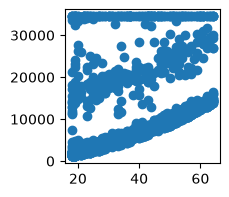

In [102]:
plt.figure(figsize=(2,2))
plt.scatter(df["age"] , df["charges"])

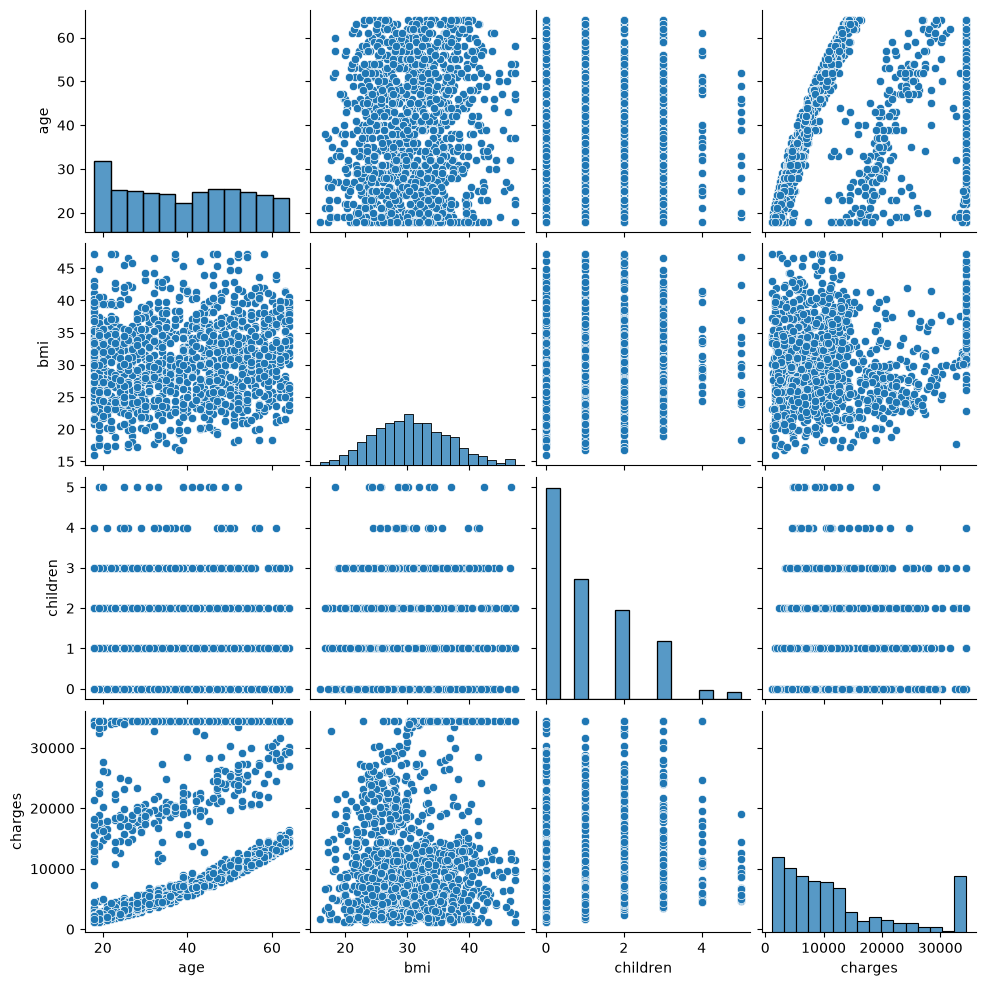

In [103]:
sns.pairplot(df)

<Axes: >

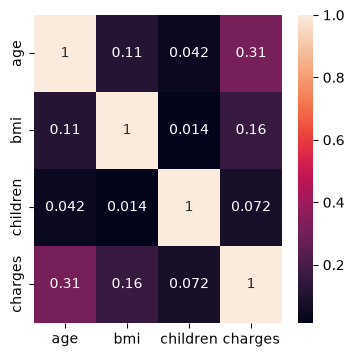

In [105]:
corr = df[num_cols].corr()
plt.figure(figsize=(len(num_cols),len(num_cols)))
sns.heatmap(corr , annot= True)